Original data shape: (62988, 44)
All data columns: ['MEMBER_NO', 'FFP_DATE', 'FIRST_FLIGHT_DATE', 'GENDER', 'FFP_TIER', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'AGE', 'LOAD_TIME', 'FLIGHT_COUNT', 'BP_SUM', 'EP_SUM_YR_1', 'EP_SUM_YR_2', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 'WEIGHTED_SEG_KM', 'LAST_FLIGHT_DATE', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM', 'BEGIN_TO_FIRST', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL', 'ADD_POINTS_SUM_YR_1', 'ADD_POINTS_SUM_YR_2', 'EXCHANGE_COUNT', 'avg_discount', 'P1Y_Flight_Count', 'L1Y_Flight_Count', 'P1Y_BP_SUM', 'L1Y_BP_SUM', 'EP_SUM', 'ADD_Point_SUM', 'Eli_Add_Point_Sum', 'L1Y_ELi_Add_Points', 'Points_Sum', 'L1Y_Points_Sum', 'Ration_L1Y_Flight_Count', 'Ration_P1Y_Flight_Count', 'Ration_P1Y_BPS', 'Ration_L1Y_BPS', 'Point_NotFlight']
Data shape after deduplication: (62988, 44)

Missing values statistics for key fields after preprocessing:
AGE                   0
avg_discount          0
FFP_TIER              0
FLIGHT_COUNT          0
WEIGHTED_SEG_KM     

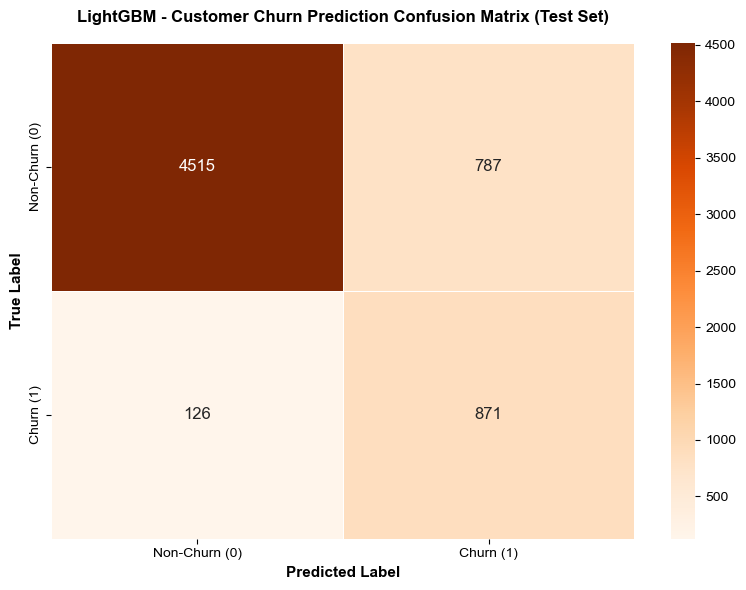


===================== Confusion Matrix Interpretation =====================
True Negatives (TN): 4515 → Correctly predicted non-churners
False Positives (FP): 787 → Falsely predicted as churners (false alarms)
False Negatives (FN): 126 → Missed actual churners (critical errors)
True Positives (TP): 871 → Correctly predicted churners (effective intervention targets)


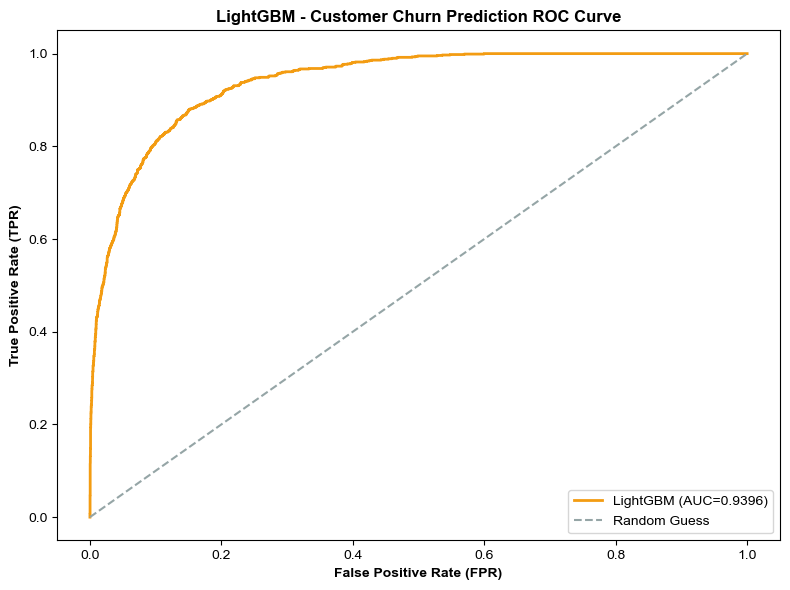

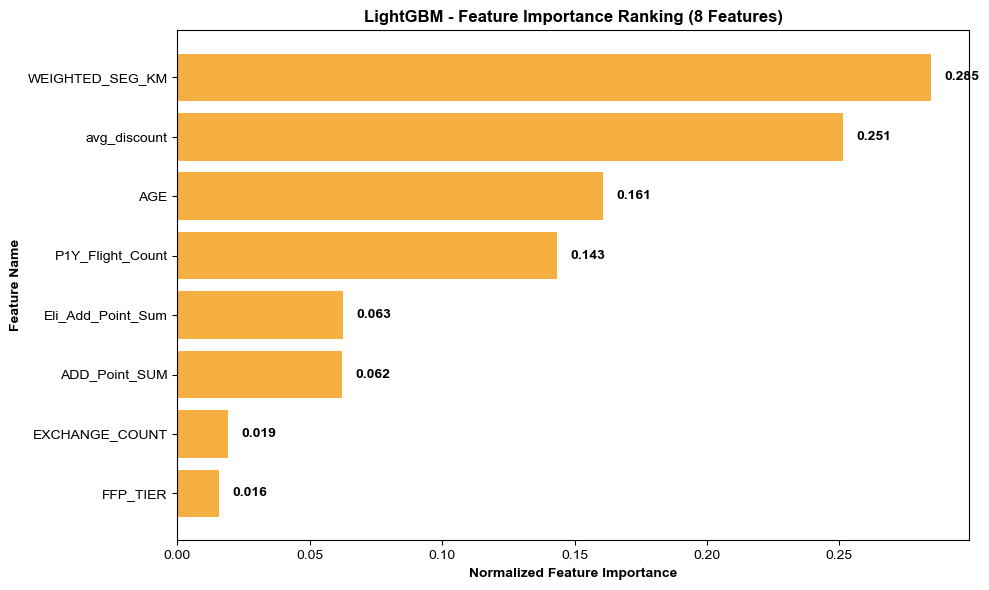

In [7]:
# ===================== Step 1: Environment Configuration & Library Import =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Add: For confusion matrix visualization
import warnings
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve, confusion_matrix  # Add: confusion_matrix
)

# Global Configuration (English font to avoid display issues)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings("ignore")  # Suppress non-critical warnings

# ===================== Step 2: Data Loading & Preprocessing =====================
def load_and_preprocess_data(file_path):
    """
    Complete data preprocessing pipeline: Keep consistent logic with previous version
    """
    df = pd.read_csv(file_path)
    print(f"Original data shape: {df.shape}")
    print(f"All data columns: {df.columns.tolist()}")

    # Remove duplicates
    df = df.drop_duplicates()
    print(f"Data shape after deduplication: {df.shape}")

    # Define feature and label columns
    feature_cols = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    label_cols = [
        "L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points",
        "P1Y_Flight_Count", "FLIGHT_COUNT", "Points_Sum"
    ]
    numeric_cols = list(set(feature_cols + label_cols))
    numeric_cols = [col for col in numeric_cols if col in df.columns]

    # Numeric conversion + missing value filling
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    print("\nMissing values statistics for key fields after preprocessing:")
    print(df[numeric_cols].isnull().sum())
    return df

# ===================== Step 3: Churn Label Definition =====================
def calculate_churn_label(df):
    """
    Churn label definition logic remains unchanged
    """
    core_label_cols = ["L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points"]
    missing_core_cols = [col for col in core_label_cols if col not in df.columns]
    if missing_core_cols:
        raise ValueError(f"Missing core fields for churn label calculation: {missing_core_cols}")

    # No behavior in last year
    inactive_now = (
        (df["L1Y_Flight_Count"] == 0) &
        (df["L1Y_Points_Sum"] == 0) &
        (df["L1Y_ELi_Add_Points"] == 0)
    )

    # Historical behavior exists
    active_conditions = []
    if "P1Y_Flight_Count" in df.columns:
        active_conditions.append(df["P1Y_Flight_Count"] > 0)
    if "FLIGHT_COUNT" in df.columns:
        active_conditions.append(df["FLIGHT_COUNT"] > 0)
    if "Points_Sum" in df.columns:
        active_conditions.append(df["Points_Sum"] > 0)
    if not active_conditions:
        raise ValueError("No available fields to judge historical active status")
    historical_active = np.logical_or.reduce(active_conditions)

    # Generate churn label
    df["is_churn"] = (inactive_now & historical_active).astype(int)
    print(f"\nChurn label distribution:")
    print(df["is_churn"].value_counts())
    print(f"Churn rate: {df['is_churn'].mean() * 100:.2f}%")
    return df

# ===================== Step 4: Stratified Data Split (8:1:1) =====================
def split_data_stratified(df, feature_list, target_col="is_churn", random_state=42):
    """
    Stratified split logic remains unchanged
    """
    X = df[feature_list].dropna()
    y = df.loc[X.index, target_col]

    # Step 1: 80% training set, 20% temp set
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    # Step 2: Split temp set into 10% test set + 10% validation set
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=random_state, stratify=y_temp
    )

    # Output split results
    print(f"\nData split results:")
    print(f"Training set: {len(X_train)} samples (Churn rate: {y_train.mean()*100:.2f}%)")
    print(f"Test set: {len(X_test)} samples (Churn rate: {y_test.mean()*100:.2f}%)")
    print(f"Validation set: {len(X_val)} samples (Churn rate: {y_val.mean()*100:.2f}%)")
    return X_train, X_test, X_val, y_train, y_test, y_val

# ===================== Step 5: LightGBM Modeling (GridSearchCV Tuning) =====================
def train_lightgbm(X_train, X_val, y_train, y_val):
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        boosting_type='gbdt',
        random_state=42,
        n_jobs=-1,
        # Add: Relax node splitting constraints
        min_child_samples=5,  # Minimum samples per leaf node (default 20, reduced)
        min_split_gain=0.0    # Minimum gain for splitting (default 0.0, ensure splitting)
    )

    # Adjust parameter grid: Relax constraints
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [5, 7],  # Increase tree depth (default -1, increased here)
        'learning_rate': [0.1, 0.2],
        'num_leaves': [63, 127],  # Increase leaf nodes (default 31, increased)
        'subsample': [0.8, 1.0],
        'scale_pos_weight': [len(y_train[y_train==0])/len(y_train[y_train==1])]
    }

    # Grid Search (3-fold cross-validation, output detailed progress)
    grid_search = GridSearchCV(
        estimator=lgb_model,
        param_grid=param_grid,
        cv=3,                  # Reduce folds to speed up training
        scoring='roc_auc',     # Use AUC as evaluation metric
        n_jobs=-1,
        verbose=2              # Output tuning progress to ensure visibility
    )

    # Train model
    print("\nStarting LightGBM GridSearchCV tuning...")
    grid_search.fit(X_train, y_train)

    # Extract best model and parameters (force output)
    best_lgb = grid_search.best_estimator_
    best_params = grid_search.best_params_
    cv_auc = grid_search.best_score_

    # Validation set evaluation
    val_proba = best_lgb.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_proba)

    # Highlight tuning results
    print(f"\n===== LightGBM Tuning Results =====")
    print(f"Best parameters: {best_params}")
    print(f"Training set cross-validation AUC: {cv_auc:.4f}")
    print(f"Validation set AUC: {val_auc:.4f}")

    return best_lgb, best_params

# ===================== Step 6: Model Evaluation & Visualization (Add Confusion Matrix) =====================
def evaluate_model(model, X_test, y_test, feature_list):
    """
    Model evaluation: Core metrics + ROC Curve + LightGBM Feature Importance + Confusion Matrix
    All labels in English to avoid display issues
    """
    # Prediction results
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    # Calculate core metrics
    metrics = {
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4)
    }

    # Print evaluation results
    print("\n===================== Model Evaluation Results =====================")
    print(f"AUC: {metrics['AUC']}")
    print(f"Churn Recall: {metrics['Recall']} (Covers {metrics['Recall']*100:.1f}% of actual churners)")
    print(f"Churn Precision: {metrics['Precision']}")
    print(f"F1 Score: {metrics['F1']}")
    print(f"Accuracy: {metrics['Accuracy']}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Non-Churn", "Churn"], digits=4))

    # 1. Confusion Matrix Visualization (New Core Feature)
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)  # Calculate confusion matrix
    # Plot heatmap with annotated values
    sns.heatmap(cm,
                annot=True,  # Show cell values
                fmt="d",  # Numeric format: integer
                cmap="Oranges",  # Color scheme matching LightGBM theme
                xticklabels=["Non-Churn (0)", "Churn (1)"],
                yticklabels=["Non-Churn (0)", "Churn (1)"],
                cbar=True,
                linewidths=0.5,
                annot_kws={"size": 12})  # Annotation font size
    plt.xlabel("Predicted Label", fontweight="bold", fontsize=11)
    plt.ylabel("True Label", fontweight="bold", fontsize=11)
    plt.title("LightGBM - Customer Churn Prediction Confusion Matrix (Test Set)", fontweight="bold", fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

    # Confusion Matrix Interpretation (Business Perspective)
    tn, fp, fn, tp = cm.ravel()
    print("\n===================== Confusion Matrix Interpretation =====================")
    print(f"True Negatives (TN): {tn} → Correctly predicted non-churners")
    print(f"False Positives (FP): {fp} → Falsely predicted as churners (false alarms)")
    print(f"False Negatives (FN): {fn} → Missed actual churners (critical errors)")
    print(f"True Positives (TP): {tp} → Correctly predicted churners (effective intervention targets)")

    # 2. ROC Curve Visualization
    plt.figure()
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, color="#f39c12", linewidth=2, label=f"LightGBM (AUC={metrics['AUC']})")
    plt.plot([0, 1], [0, 1], color="#95a5a6", linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate (FPR)", fontweight="bold")
    plt.ylabel("True Positive Rate (TPR)", fontweight="bold")
    plt.title("LightGBM - Customer Churn Prediction ROC Curve", fontweight="bold")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # 3. LightGBM Feature Importance Visualization
    plt.figure(figsize=(10, 6))
    importance = model.feature_importances_  # LightGBM native feature importance
    imp_df = pd.DataFrame({
        "Feature": feature_list,
        "Importance": importance / importance.sum()  # Normalization
    }).sort_values("Importance", ascending=True)

    plt.barh(imp_df["Feature"], imp_df["Importance"], color="#f39c12", alpha=0.8)
    for i, val in enumerate(imp_df["Importance"]):
        plt.text(val + 0.005, i, f"{val:.3f}", ha="left", va="center", fontweight="bold")
    plt.xlabel("Normalized Feature Importance", fontweight="bold")
    plt.ylabel("Feature Name", fontweight="bold")
    plt.title("LightGBM - Feature Importance Ranking (8 Features)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return metrics

# ===================== Main Pipeline Execution =====================
if __name__ == "__main__":
    # 1. Data path (replace with your actual path)
    FILE_PATH = "/Users/mac123/Downloads/air_data.csv"

    # 2. Data preprocessing
    df = load_and_preprocess_data(FILE_PATH)

    # 3. Generate churn label
    df = calculate_churn_label(df)

    # 4. Feature list (specified 8 features)
    FEATURE_LIST = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    # Filter features present in data
    FEATURE_LIST = [col for col in FEATURE_LIST if col in df.columns]
    print(f"\nFinal feature list used: {FEATURE_LIST}")

    # Verify feature count
    if len(FEATURE_LIST) != 8:
        missing_feat = [f for f in ['FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
                                    'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum']
                        if f not in FEATURE_LIST]
        print(f"Warning: Missing specified features {missing_feat}. Currently using {len(FEATURE_LIST)} features.")

    # 5. Stratified data split
    X_train, X_test, X_val, y_train, y_test, y_val = split_data_stratified(df, FEATURE_LIST)

    # 6. Train LightGBM model
    best_lgb_model, best_params = train_lightgbm(X_train, X_val, y_train, y_val)

    # 7. Model evaluation (including confusion matrix)
    metrics = evaluate_model(best_lgb_model, X_test, y_test, FEATURE_LIST)